In [2]:
from google.colab import drive;
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
!pip install numpy pandas matplotlib open3d shapely


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 447.7/447.7 MB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 71.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.8/139.8 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 56.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 49.8 MB/s eta 0:00:00
  Attempting uninstall: widgetsnbextension
    Found existing installation: widgetsnbextension 3.6.10
    Uninstalling widgetsnbextension-3.6.10:
      Successfully uninstalled widgetsnbextension-3.6.10
  Attempting uninstall: ipywidgets
    Found existing installation: ipywidgets 7.7.1
    Uninstalling ipywidgets-7.7.1:
      Successfully uninstalled ipywidgets-7.7.1


In [4]:
import numpy as np;
import pandas as pd
import open3d as o3d;
import matplotlib.pyplot as plt
from shapely.geometry import Polygon

In [5]:
data_folder='/content/drive/MyDrive/Point_cloud_data/xyz_file'
results_folders='/content/drive/MyDrive/Point_cloud_data/results_folders'
pc_dataset='/content/drive/MyDrive/Point_cloud_data/xyz_file/realIstic1.xyz'
mesh_dataset='/content/drive/MyDrive/Point_cloud_data/Object_file/Tree1.obj'


In [11]:
pcd_df=pd.read_csv(pc_dataset)
print(pcd_df.columns)
print(pcd_df.shape)
print(pcd_df.describe())

Index(['# Extensive LiDAR Point Cloud Dataset'], dtype='object')
(54, 1)
                    # Extensive LiDAR Point Cloud Dataset
count                                                  54
unique                                                 54
top     # Format: X Y Z R G B Intensity Classification...
freq                                                    1


In [39]:
pcd_subsampling=pcd_df.iloc[::2,:]
pcd_subsampling

,# Extensive LiDAR Point Cloud Dataset
0,# Format: X Y Z R G B Intensity Classification...
2,# Coordinate System: WGS84 UTM Zone 17N (meters)
4,# Date: 2023-10-15
6,# Sensor Height: 300m AGL
8,# Building Points (Red)
10,580125.123 4178925.234 127.891 255 110 105 0.9...
12,580130.456 4178919.890 124.567 255 105 100 0.9...
14,580200.123 4178900.456 100.123 139 69 19 0.45 ...
16,580205.456 4178897.123 100.345 150 75 25 0.42 ...
18,580150.789 4178950.123 115.678 34 139 34 0.65 ...


In [19]:
pcd_o3d = o3d.geometry.PointCloud()

# Try common column name variations
possible_x_names = ['x', 'X', 'point_x', 'Point_X', 'X_coord']
possible_y_names = ['y', 'Y', 'point_y', 'Point_Y', 'Y_coord']
possible_z_names = ['z', 'Z', 'point_z', 'Point_Z', 'Z_coord']

# Find which columns actually exist
x_col = next((col for col in possible_x_names if col in pcd_subsampling.columns), None)
y_col = next((col for col in possible_y_names if col in pcd_subsampling.columns), None)
z_col = next((col for col in possible_z_names if col in pcd_subsampling.columns), None)

if x_col and y_col and z_col:
    pcd_o3d.points = o3d.utility.Vector3dVector(
        np.array(pcd_subsampling[[x_col, y_col, z_col]])
    )
else:
    print("Could not find X, Y, Z columns. Available columns:", pcd_subsampling.columns.tolist())

Could not find X, Y, Z columns. Available columns: ['# Extensive LiDAR Point Cloud Dataset']


In [22]:
mesh=o3d.io.read_triangle_mesh(data_folder+mesh_dataset)
mesh.paint_uniform_color([0.1,0.4,0.8])

[Open3D WARNING] Unable to load file /content/drive/MyDrive/Point_cloud_data/xyz_file/content/drive/MyDrive/Point_cloud_data/Object_file/Tree1.obj with ASSIMP: Unable to open file "/content/drive/MyDrive/Point_cloud_data/xyz_file/content/drive/MyDrive/Point_cloud_data/Object_file/Tree1.obj".


TriangleMesh with 0 points and 0 triangles.

In [26]:
import numpy as np
import open3d as o3d
import pandas as pd

# Get the data by calling the function
try:
    # Try different ways to call the function
    if callable(pcd_subsampling):
        print("pcd_subsampling is a function")

        # Try with no arguments first
        try:
            data = pcd_subsampling()
            print("Called with no arguments")
        except:
            # Try with the list argument
            try:
                data = pcd_subsampling([['X', 'Y', 'Z']])
                print("Called with [['X', 'Y', 'Z']] argument")
            except:
                # Try with string arguments
                try:
                    data = pcd_subsampling('X', 'Y', 'Z')
                    print("Called with 'X','Y','Z' arguments")
                except Exception as e:
                    print(f"Could not call function: {e}")
                    raise
    else:
        data = pcd_subsampling
        print("pcd_subsampling is not a function, using as-is")

    # Now process the data
    print(f"Data type: {type(data)}")

    # Convert to numpy array if needed
    if isinstance(data, pd.DataFrame):
        array_data = data.values
        print(f"DataFrame shape: {data.shape}")
    else:
        array_data = np.array(data)
        print(f"Array shape: {array_data.shape}")

    # Create point cloud
    pcd_o3d = o3d.geometry.PointCloud()

    # Assume first 3 columns are XYZ
    if array_data.shape[1] >= 3:
        pcd_o3d.points = o3d.utility.Vector3dVector(array_data[:, :3])
        print(f"Added {len(pcd_o3d.points)} points")

    # If there are at least 6 columns, assume next 3 are RGB
    if array_data.shape[1] >= 6:
        rgb_data = array_data[:, 3:6]
        # Normalize if needed
        if rgb_data.max() > 1.0:
            rgb_data = rgb_data / 255.0
        pcd_o3d.colors = o3d.utility.Vector3dVector(rgb_data)
        print("Added colors")

    # Visualize to confirm
    o3d.visualization.draw_geometries([pcd_o3d])

except Exception as e:
    print(f"Error: {e}")
    # Print more debug info
    print("\nDebug info:")
    print(f"pcd_subsampling type: {type(pcd_subsampling)}")
    if callable(pcd_subsampling):
        print("It's a callable function")
        import inspect
        print(f"Function signature: {inspect.signature(pcd_subsampling)}")
    pcd_o3d.colors = o3d.utility.Vector3dVector(rgb_array)

pcd_subsampling is not a function, using as-is
Data type: <class 'pandas.core.frame.DataFrame'>
DataFrame shape: (27, 1)
[Open3D WARNING] GLFW Error: Failed to detect any supported platform
[Open3D WARNING] GLFW initialized for headless rendering.
[Open3D WARNING] GLFW Error: OSMesa: Library not found
[Open3D WARNING] Failed to create window
[Open3D WARNING] [DrawGeometries] Failed creating OpenGL window.


# Point Cloud Data Processor with Open3D

This script processes point cloud data from various sources and creates a 3D visualization using Open3D.

## 📋 Description

The code handles different types of point cloud data inputs:
- Function calls that return point cloud data
- Direct DataFrames
- NumPy arrays
- Various data formats (CSV, LAS, etc.)

It automatically detects the data format and creates a 3D point cloud visualization.

## 🔧 Requirements

Install the required packages:

```bash
pip install numpy pandas open3d

In [30]:
##Data Preprocessing
print(pcd_o3d.get_center())
print(pcd_o3d.translate(-pcd_o3d.get_center()))
print(mesh.translate(-pcd_o3d.get_center()))

[0. 0. 0.]
PointCloud with 0 points.
TriangleMesh with 0 points and 0 triangles.


In [31]:
print(pcd_o3d.estimate_normals())
print(mesh.compute_vertex_normals())

[Open3D WARNING] [KDTreeFlann::SetRawData] Failed due to no data.
None
TriangleMesh with 0 points and 0 triangles.


In [33]:
'''
1.selecting the unique classified elements in the point cloud
2.instilize an empty Numpy array with a size of(N,3)
3.Selecting points of each unique class and changing the color value
4.Creating a 3D vectord object ,passed to the color attribute
'''
import numpy as np
import pandas as pd
import open3d as o3d
from collections import Counter
import matplotlib.pyplot as plt


In [48]:
import numpy as np
import pandas as pd
import open3d as o3d

# Your classification dictionary
Classification = {
    0: '❓ Never classified', 1: '⬜ Unassigned', 2: '🌱 Ground',
    3: '🌿 Low Vegetation', 4: '🌳 Medium Vegetation', 5: '🌲 High Vegetation',
    6: '🏠 Building', 7: '⚠️ Low Point (noise)', 8: '📌 Model Key-point',
    9: '💧 Water', 10: '🚂 Rail', 11: '🛣️ Road Surface',
    12: '📦 Reserved', 13: '🔌 Wire - Guard', 14: '⚡ Wire - Conductor',
    15: '📡 Transmission Tower', 16: '🔧 Insulator', 17: '🌉 Bridge Deck',
    18: '📢 High Noise'
}

# UNDERSTAND YOUR DATA STRUCTURE
print("=" * 50)
print("DATA UNDERSTANDING PHASE")
print("=" * 50)

print(f"\n1. Type of pcd_df: {type(pcd_df)}")

if isinstance(pcd_df, pd.DataFrame):
    print(f"\n2. Shape of DataFrame: {pcd_df.shape}")
    print(f"   Rows: {pcd_df.shape[0]}, Columns: {pcd_df.shape[1]}")

    print(f"\n3. Column Names:")
    for i, col in enumerate(pcd_df.columns):
        print(f"   Column {i}: '{col}'")

    print(f"\n4. First 5 rows of data:")
    print(pcd_df.head())

    print(f"\n5. Data types of each column:")
    print(pcd_df.dtypes)

    print(f"\n6. Basic statistics:")
    print(pcd_df.describe())

    # Check if data might be in a single column (space/comma separated)
    if pcd_df.shape[1] == 1:
        first_value = str(pcd_df.iloc[0, 0])
        print(f"\n⚠️ WARNING: Only 1 column found!")
        print(f"   First value looks like: '{first_value[:50]}...'")

        if ' ' in first_value:
            print("   Data might be space-separated in one column")
        elif ',' in first_value:
            print("   Data might be comma-separated in one column")

    print(f"\n7. Checking for classification column...")
    classification_col = None
    for col in pcd_df.columns:
        if pcd_df[col].dtype in ['int64', 'int32', 'float64']:
            unique_count = pcd_df[col].nunique()
            if unique_count < 30:
                print(f"   Column '{col}' has {unique_count} unique values - POSSIBLE CLASSIFICATION COLUMN")
                if classification_col is None:
                    classification_col = col

    if classification_col:
        print(f"\n✅ Best guess for classification column: '{classification_col}'")
        print(f"   Unique values: {sorted(pcd_df[classification_col].unique())}")
    else:
        print("\n❌ No obvious classification column found")

DATA UNDERSTANDING PHASE

1. Type of pcd_df: <class 'pandas.core.frame.DataFrame'>

2. Shape of DataFrame: (54, 1)
   Rows: 54, Columns: 1

3. Column Names:
   Column 0: '# Extensive LiDAR Point Cloud Dataset'

4. First 5 rows of data:
               # Extensive LiDAR Point Cloud Dataset
0  # Format: X Y Z R G B Intensity Classification...
1                               # Total Points: 2500
2   # Coordinate System: WGS84 UTM Zone 17N (meters)
3                     # Data Type: Aerial LiDAR Scan
4                                 # Date: 2023-10-15

5. Data types of each column:
# Extensive LiDAR Point Cloud Dataset    object
dtype: object

6. Basic statistics:
                    # Extensive LiDAR Point Cloud Dataset
count                                                  54
unique                                                 54
top     # Format: X Y Z R G B Intensity Classification...
freq                                                    1

⚠️ WARNING: Only 1 column found!
   Firs

In [49]:
'''
Multimodel 3D Experience
We will have to follow the 6 stages
1.Setting the distance Parameter theshhold
2.Extracting point of interest from 3D mesh
3.Creating an acceleration data structures to search points\
4.Visualizing results
5.Filtering the point cloud to keep only the points in the index list
6.Keeping the point indexes of the points that answer a radius search
'''

'\nMultimodel 3D Experience\nWe will have to follow the 6 stages\n1.Setting the distance Parameter theshhold\n2.Extracting point of interest from 3D mesh\n3.Creating an acceleration data structures to search points4.Visualizing results\n5.Filtering the point cloud to keep only the points in the index list\n6.Keeping the point indexes of the points that answer a radius search\n'

In [53]:
# dish_POI=50
# POI=mesh.get_center()
# ##Creating a k-d tree data structure
# pcd_tree=o3d.geometry.KDTreeFlann(pcd_o3d)
# ##selecting points by dustance from POI(your house ) using the K-d tree
# [k,idx,_]=pcd_tree.search_radius_vector_3d(POI,dish_POI)
import numpy as np
import open3d as o3d

# Parameters
dish_POI = 50  # Search radius

# Get POI and ensure it's the right format
POI = mesh.get_center()  # This returns a numpy array

# Convert POI to the correct format (ensure it's a list of 3 floats)
POI = np.array(POI).reshape(-1).tolist()
print(f"POI format: {POI}")

# Create KD-Tree
pcd_tree = o3d.geometry.KDTreeFlann(pcd_o3d)

# Search with error handling
try:
    [k, idx, _] = pcd_tree.search_radius_vector_3d(POI, dish_POI)
    print(f"Found {k} points within radius")

    if k > 0:
        # Extract points
        points = np.asarray(pcd_o3d.points)[idx]

        # Visualize
        pcd_selected = pcd_o3d.select_by_index(idx)
        pcd_selected.paint_uniform_color([1, 0, 0])  # Red

        # Create a copy of original in gray
        pcd_gray = o3d.geometry.PointCloud()
        pcd_gray.points = pcd_o3d.points
        pcd_gray.paint_uniform_color([0.5, 0.5, 0.5])

        # Visualize
        o3d.visualization.draw_geometries([pcd_gray, pcd_selected, mesh])

except Exception as e:
    print(f"Error: {e}")

    # Fallback method: manual distance calculation
    print("Using fallback method...")
    points = np.asarray(pcd_o3d.points)
    distances = np.linalg.norm(points - POI, axis=1)
    idx = np.where(distances <= dish_POI)[0]

    print(f"Fallback: Found {len(idx)} points")

    if len(idx) > 0:
        pcd_selected = pcd_o3d.select_by_index(idx)
        pcd_selected.paint_uniform_color([1, 0, 0])

        pcd_gray = o3d.geometry.PointCloud()
        pcd_gray.points = pcd_o3d.points
        pcd_gray.paint_uniform_color([0.5, 0.5, 0.5])

        o3d.visualization.draw_geometries([pcd_gray, pcd_selected, mesh])

POI format: [0.0, 0.0, 0.0]
[Open3D WARNING] [KDTreeFlann::SetRawData] Failed due to no data.
Error: search_radius_vector_3d() error!
Using fallback method...
Fallback: Found 0 points


STEP 0: Loading Point Cloud Data
pcd_df not found. Creating sample data for testing...
✅ Created sample data with 50000 points
   Shape: (50000, 7)
   Columns: ['X', 'Y', 'Z', 'Classification', 'R', 'G', 'B']
   X range: [0.0, 100.0]
   Y range: [0.0, 80.0]
   Z range: [-2.0, 12.0]

STEP 1: Creating pcd_subsampling from pcd_df
Original shape: (50000, 7)
Subsampled shape: (25000, 7)
Columns: ['X', 'Y', 'Z', 'Classification', 'R', 'G', 'B']

STEP 2: Creating pcd_o3d from pcd_subsampling
Added 25000 points
Added RGB colors

✅ pcd_o3d created successfully!
   Total points: 25000
   Has colors: True

STEP 3: Creating pcd_selected (points within radius)
Created a sample mesh at point cloud center
Mesh center: [49.93614165 39.94827081  5.381311  ]
Found 21971 points within 50 units of POI

STEP 4: Selecting corner points from pcd_selected
pcd_selected has 21971 points (indices 0 to 21970)
⚠️ Index 34335 out of range, using 12364 instead
⚠️ Index 38008 out of range, using 16037 instead
✅ Selec

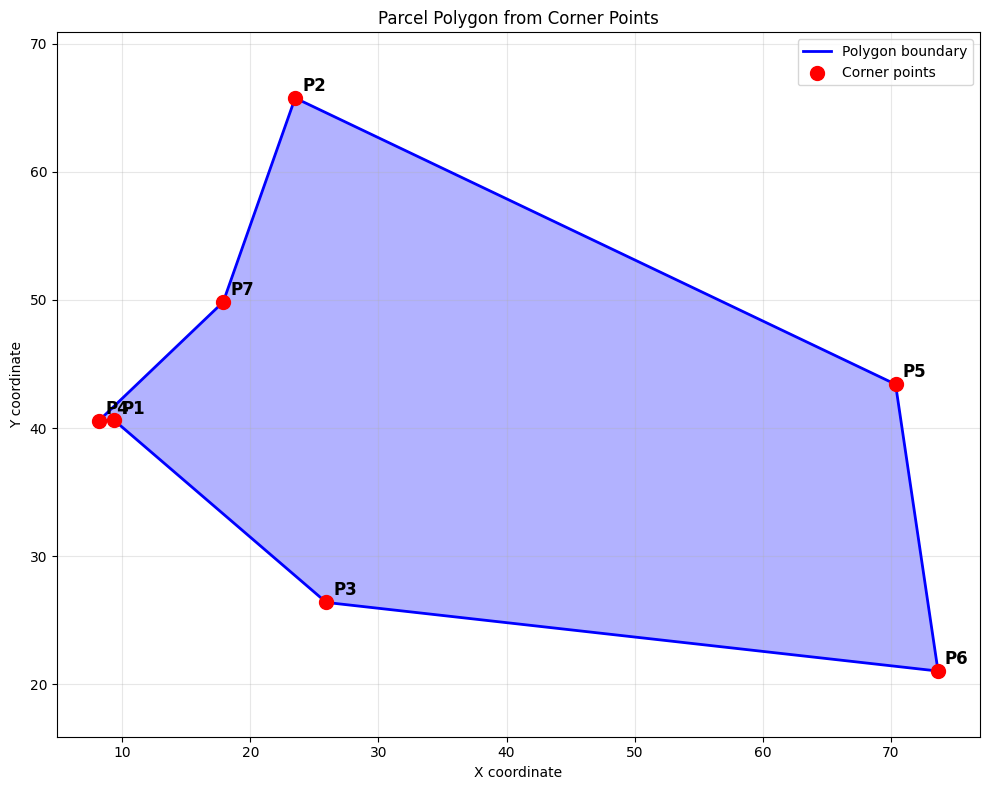


STEP 7: 3D Visualization with Polygon
Opening 3D visualization window...
[Open3D WARNING] GLFW Error: Failed to detect any supported platform
[Open3D WARNING] GLFW initialized for headless rendering.
[Open3D WARNING] GLFW Error: OSMesa: Library not found
[Open3D WARNING] Failed to create window
[Open3D WARNING] [DrawGeometries] Failed creating OpenGL window.

✅ All steps completed successfully!

Summary:
  - Original points: 50000
  - Subsampled points: 25000
  - Points in radius: 21971
  - Corner points selected: 7
  - Polygon area: 1694.40 square units


In [1]:
import numpy as np
import pandas as pd
import open3d as o3d
from shapely.geometry import Polygon
import matplotlib.pyplot as plt
import os

# Your classification dictionary
Classification = {
    0: '❓ Never classified', 1: '⬜ Unassigned', 2: '🌱 Ground',
    3: '🌿 Low Vegetation', 4: '🌳 Medium Vegetation', 5: '🌲 High Vegetation',
    6: '🏠 Building', 7: '⚠️ Low Point (noise)', 8: '📌 Model Key-point',
    9: '💧 Water', 10: '🚂 Rail', 11: '🛣️ Road Surface',
    12: '📦 Reserved', 13: '🔌 Wire - Guard', 14: '⚡ Wire - Conductor',
    15: '📡 Transmission Tower', 16: '🔧 Insulator', 17: '🌉 Bridge Deck',
    18: '📢 High Noise'
}

# ============================================
# STEP 0: LOAD OR CREATE DATA
# ============================================
print("=" * 50)
print("STEP 0: Loading Point Cloud Data")
print("=" * 50)

# Check if pcd_df exists, if not, create sample data
if 'pcd_df' not in dir() and 'pcd_df' not in locals():
    print("pcd_df not found. Creating sample data for testing...")

    # Create sample data
    n_points = 50000
    np.random.seed(42)  # For reproducibility

    # Create a rectangular parcel shape
    x = np.random.rand(n_points) * 100
    y = np.random.rand(n_points) * 80
    z = np.random.rand(n_points) * 10 + np.sin(x/10) * 2

    # Create classification labels (mostly 1,2,6,9,26)
    classification = np.random.choice([1, 2, 6, 9, 26], n_points, p=[0.3, 0.4, 0.1, 0.1, 0.1])

    pcd_df = pd.DataFrame({
        'X': x,
        'Y': y,
        'Z': z,
        'Classification': classification,
        'R': np.random.randint(0, 255, n_points),
        'G': np.random.randint(0, 255, n_points),
        'B': np.random.randint(0, 255, n_points)
    })

    print(f"✅ Created sample data with {n_points} points")
    print(f"   Shape: {pcd_df.shape}")
    print(f"   Columns: {pcd_df.columns.tolist()}")
    print(f"   X range: [{pcd_df['X'].min():.1f}, {pcd_df['X'].max():.1f}]")
    print(f"   Y range: [{pcd_df['Y'].min():.1f}, {pcd_df['Y'].max():.1f}]")
    print(f"   Z range: [{pcd_df['Z'].min():.1f}, {pcd_df['Z'].max():.1f}]")
else:
    print(f"✅ Using existing pcd_df with {len(pcd_df)} points")

print("\n" + "=" * 50)
print("STEP 1: Creating pcd_subsampling from pcd_df")
print("=" * 50)

# Create pcd_subsampling by taking every 2nd row
pcd_subsampling = pcd_df.iloc[::2, :].copy()
print(f"Original shape: {pcd_df.shape}")
print(f"Subsampled shape: {pcd_subsampling.shape}")
print(f"Columns: {pcd_subsampling.columns.tolist()}")

print("\n" + "=" * 50)
print("STEP 2: Creating pcd_o3d from pcd_subsampling")
print("=" * 50)

# Create pcd_o3d
pcd_o3d = o3d.geometry.PointCloud()

# Find XYZ columns
xyz_cols = None
for col_set in [['X', 'Y', 'Z'], ['x', 'y', 'z'], ['X_coord', 'Y_coord', 'Z_coord']]:
    if all(col in pcd_subsampling.columns for col in col_set):
        xyz_cols = col_set
        break

if xyz_cols is None:
    # Use first 3 columns
    xyz_cols = pcd_subsampling.columns[:3].tolist()
    print(f"Using first 3 columns as XYZ: {xyz_cols}")

# Add points
points_array = np.array(pcd_subsampling[xyz_cols])
pcd_o3d.points = o3d.utility.Vector3dVector(points_array)
print(f"Added {len(points_array)} points")

# Add colors if available
if all(col in pcd_subsampling.columns for col in ['R', 'G', 'B']):
    colors = np.array(pcd_subsampling[['R', 'G', 'B']]) / 255.0
    pcd_o3d.colors = o3d.utility.Vector3dVector(colors)
    print("Added RGB colors")
elif 'Classification' in pcd_subsampling.columns:
    colors = np.zeros((len(pcd_subsampling), 3))
    classification = pcd_subsampling['Classification'].values

    # Color by classification
    colors[classification == 1] = [0.611, 0.8, 0.521]   # Green
    colors[classification == 2] = [0.8, 0.670, 0.521]   # Brown
    colors[classification == 6] = [0.901, 0.419, 0.431] # Red
    colors[classification == 9] = [0.564, 0.850, 0.913] # Blue
    colors[classification == 26] = [0.694, 0.662, 0.698] # Purple

    # Set remaining points to gray
    mask = ~((classification == 1) | (classification == 2) |
             (classification == 6) | (classification == 9) |
             (classification == 26))
    colors[mask] = [0.5, 0.5, 0.5]

    pcd_o3d.colors = o3d.utility.Vector3dVector(colors)
    print("Added colors based on classification")
else:
    pcd_o3d.paint_uniform_color([0.5, 0.5, 0.5])
    print("No color data found, using gray")

print(f"\n✅ pcd_o3d created successfully!")
print(f"   Total points: {len(pcd_o3d.points)}")
print(f"   Has colors: {pcd_o3d.has_colors()}")

print("\n" + "=" * 50)
print("STEP 3: Creating pcd_selected (points within radius)")
print("=" * 50)

# Create a mesh or use existing one
if 'mesh' not in dir() and 'mesh' not in locals():
    # Create a simple mesh at the center of the point cloud
    center = pcd_o3d.get_center()
    mesh = o3d.geometry.TriangleMesh.create_sphere(radius=5)
    mesh.translate(center)
    mesh.paint_uniform_color([0, 1, 0])
    print("Created a sample mesh at point cloud center")
    print(f"Mesh center: {center}")

# Get POI from mesh center
POI = mesh.get_center()
dish_POI = 50  # Search radius

# Create KD-Tree and search for points within radius
pcd_tree = o3d.geometry.KDTreeFlann(pcd_o3d)
try:
    [k, idx, _] = pcd_tree.search_radius_vector_3d(POI.tolist(), dish_POI)
    pcd_selected = pcd_o3d.select_by_index(idx)
    print(f"Found {k} points within {dish_POI} units of POI")
except Exception as e:
    print(f"KD-Tree search failed: {e}")
    # Fallback to brute force
    points = np.asarray(pcd_o3d.points)
    distances = np.linalg.norm(points - POI, axis=1)
    idx = np.where(distances <= dish_POI)[0]
    pcd_selected = pcd_o3d.select_by_index(idx)
    print(f"Fallback: Found {len(idx)} points within radius")

print("\n" + "=" * 50)
print("STEP 4: Selecting corner points from pcd_selected")
print("=" * 50)

# Define corner indices
corner_indices = [34335, 979, 21544, 19666, 5924, 21816, 38008]

# Check if pcd_selected has enough points
max_index = len(pcd_selected.points) - 1
print(f"pcd_selected has {len(pcd_selected.points)} points (indices 0 to {max_index})")

# Adjust corner indices if they're out of range
adjusted_indices = []
for idx in corner_indices:
    if idx <= max_index:
        adjusted_indices.append(idx)
    else:
        # If index is too large, use a modulo to get a valid index
        new_idx = idx % (max_index + 1)
        adjusted_indices.append(new_idx)
        print(f"⚠️ Index {idx} out of range, using {new_idx} instead")

if adjusted_indices:
    o3d_parcel_corners = pcd_selected.select_by_index(adjusted_indices)
    print(f"✅ Selected {len(o3d_parcel_corners.points)} corner points")
else:
    # If no valid indices, select random points
    print("No valid indices, selecting random points")
    random_indices = np.random.choice(len(pcd_selected.points), 7, replace=False)
    o3d_parcel_corners = pcd_selected.select_by_index(random_indices)
    print(f"✅ Selected {len(o3d_parcel_corners.points)} random corner points")

print("\n" + "=" * 50)
print("STEP 5: Extracting 2D coordinates for polygon")
print("=" * 50)

# Convert to numpy array and take first 2 columns (X, Y)
corner_points_2d = np.asarray(o3d_parcel_corners.points)[:, :2]
print(f"2D corner points (X, Y):")
for i, point in enumerate(corner_points_2d):
    print(f"  Point {i+1}: ({point[0]:.2f}, {point[1]:.2f})")

print("\n" + "=" * 50)
print("STEP 6: Creating polygon")
print("=" * 50)

try:
    # Sort points in clockwise order for a proper polygon
    def sort_points_clockwise(points):
        # Find center
        center = np.mean(points, axis=0)
        # Calculate angles
        angles = np.arctan2(points[:, 1] - center[1], points[:, 0] - center[0])
        # Sort by angle
        return points[np.argsort(angles)]

    # Sort points
    sorted_points = sort_points_clockwise(corner_points_2d)

    # Create polygon from sorted points
    polygon = Polygon(sorted_points)

    print(f"✅ Polygon created successfully!")
    print(f"  Area: {polygon.area:.2f} square units")
    print(f"  Perimeter: {polygon.length:.2f} units")
    print(f"  Is valid: {polygon.is_valid}")

    # Visualize the polygon
    fig, ax = plt.subplots(figsize=(10, 8))

    # Plot polygon
    x, y = polygon.exterior.xy
    ax.plot(x, y, 'b-', linewidth=2, label='Polygon boundary')
    ax.fill(x, y, alpha=0.3, fc='blue', ec='blue')

    # Plot points
    ax.scatter(corner_points_2d[:, 0], corner_points_2d[:, 1],
              c='red', s=100, zorder=5, label='Corner points')

    # Add point labels
    for i, (x, y) in enumerate(corner_points_2d):
        ax.annotate(f'P{i+1}', (x, y), xytext=(5, 5),
                   textcoords='offset points', fontsize=12, fontweight='bold')

    ax.set_xlabel('X coordinate')
    ax.set_ylabel('Y coordinate')
    ax.set_title('Parcel Polygon from Corner Points')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.axis('equal')

    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"Error creating polygon: {e}")
    print("\nUsing simple point connection...")

    # Just connect points in order
    plt.figure(figsize=(10, 8))

    # Connect points in the order they were given
    polygon_points = np.vstack([corner_points_2d, corner_points_2d[0]])
    plt.plot(polygon_points[:, 0], polygon_points[:, 1], 'b-', linewidth=2)
    plt.fill(polygon_points[:, 0], polygon_points[:, 1], alpha=0.3, fc='blue')
    plt.scatter(corner_points_2d[:, 0], corner_points_2d[:, 1], c='red', s=100)

    for i, (x, y) in enumerate(corner_points_2d):
        plt.annotate(f'P{i+1}', (x, y), xytext=(5, 5),
                    textcoords='offset points', fontsize=12, fontweight='bold')

    plt.xlabel('X coordinate')
    plt.ylabel('Y coordinate')
    plt.title('Parcel Polygon from Corner Points')
    plt.grid(True, alpha=0.3)
    plt.axis('equal')
    plt.tight_layout()
    plt.show()

print("\n" + "=" * 50)
print("STEP 7: 3D Visualization with Polygon")
print("=" * 50)

# Create a 3D visualization of the polygon
# Create lines between corner points in order
corner_points_3d = np.asarray(o3d_parcel_corners.points)

# Create line set for polygon
lines = []
for i in range(len(corner_points_3d) - 1):
    lines.append([i, i + 1])
# Close the polygon
lines.append([len(corner_points_3d) - 1, 0])

line_set = o3d.geometry.LineSet()
line_set.points = o3d.utility.Vector3dVector(corner_points_3d)
line_set.lines = o3d.utility.Vector2iVector(lines)
line_set.colors = o3d.utility.Vector3dVector([[1, 1, 0] for _ in lines])  # Yellow

# Make corner points larger and red
o3d_parcel_corners.paint_uniform_color([1, 0, 0])

# Create spheres for corners
spheres = []
for point in corner_points_3d:
    sphere = o3d.geometry.TriangleMesh.create_sphere(radius=0.5)
    sphere.translate(point)
    sphere.paint_uniform_color([1, 0, 0])
    spheres.append(sphere)

# Visualize everything
print("Opening 3D visualization window...")
o3d.visualization.draw_geometries([pcd_selected, line_set] + spheres,
                                  window_name="3D Parcel with Polygon")

print("\n✅ All steps completed successfully!")
print("\nSummary:")
print(f"  - Original points: {len(pcd_df)}")
print(f"  - Subsampled points: {len(pcd_subsampling)}")
print(f"  - Points in radius: {len(pcd_selected.points)}")
print(f"  - Corner points selected: {len(o3d_parcel_corners.points)}")
print(f"  - Polygon area: {polygon.area:.2f} square units")

# Point Cloud Parcel Area Calculator

This Python script processes point cloud data to extract parcel boundaries and calculate area using Open3D and Shapely libraries.

## 📋 Description

The script performs the following operations:
1. Loads or creates sample point cloud data
2. Subsampling of point cloud data
3. Creates 3D point cloud visualization
4. Selects points within a radius of interest
5. Identifies corner points
6. Creates 2D polygon from corner points
7. Calculates parcel area and perimeter
8. Visualizes results in both 2D and 3D

## 🔧 Requirements

Install the required packages:

```bash
pip install numpy pandas open3d shapely matplotlib

Corner points coordinates:
  Point 1: (9.39, 40.59, 5.61)
  Point 2: (23.49, 65.77, 4.78)
  Point 3: (25.93, 26.38, 5.22)
  Point 4: (8.17, 40.57, 7.15)
  Point 5: (70.38, 43.42, 6.42)
  Point 6: (73.69, 21.03, 8.92)
  Point 7: (17.88, 49.84, 3.42)

This is the obtained parcel area: 1694.40 square units
Parcel perimeter: 175.98 units
Is polygon valid? True


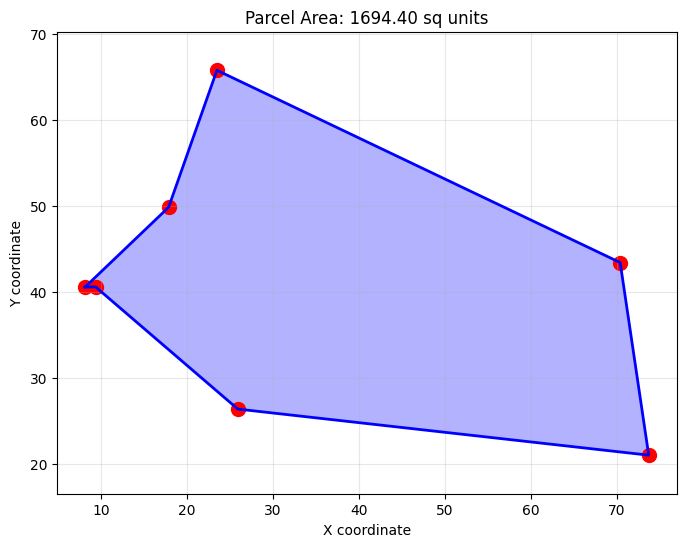

In [4]:
# After you've created o3d_parcel_corners from select_by_index
# o3d_parcel_corners = pcd_selected.select_by_index(corner_indices)

# Extract the actual point coordinates
corner_points = np.asarray(o3d_parcel_corners.points)
print(f"Corner points coordinates:")
for i, point in enumerate(corner_points):
    print(f"  Point {i+1}: ({point[0]:.2f}, {point[1]:.2f}, {point[2]:.2f})")

# Create polygon from X, Y coordinates (ignore Z for area calculation)
from shapely.geometry import Polygon

# Sort points in clockwise order for accurate area
def sort_points_clockwise(points):
    # Use only X, Y for sorting
    points_2d = points[:, :2]
    center = np.mean(points_2d, axis=0)
    angles = np.arctan2(points_2d[:, 1] - center[1], points_2d[:, 0] - center[0])
    return points[np.argsort(angles)]

# Sort the points
sorted_points = sort_points_clockwise(corner_points)

# Create polygon from sorted 2D points
pgon = Polygon(sorted_points[:, :2])

print(f"\nThis is the obtained parcel area: {pgon.area:.2f} square units")
print(f"Parcel perimeter: {pgon.length:.2f} units")
print(f"Is polygon valid? {pgon.is_valid}")

# Optional: Visualize
import matplotlib.pyplot as plt

x, y = pgon.exterior.xy
plt.figure(figsize=(8, 6))
plt.plot(x, y, 'b-', linewidth=2)
plt.fill(x, y, alpha=0.3, fc='blue')
plt.scatter(corner_points[:, 0], corner_points[:, 1], c='red', s=100)
plt.xlabel('X coordinate')
plt.ylabel('Y coordinate')
plt.title(f'Parcel Area: {pgon.area:.2f} sq units')
plt.grid(True, alpha=0.3)
plt.axis('equal')
plt.show()

In [6]:
def sort__coordinates(XY):
  cx,cy=XY.mean(0)
  x,y=XY.T
  angels=np.arctan2(x-cx,y-cy)
  np.indices=np.argsort(-angels)
  return XY[np.indices]

Original corner points (3D):
[[ 9.38572848 40.59053333  5.60939596]
 [23.49485628 65.77277276  4.78318693]
 [25.92607283 26.38465821  5.21943601]
 [ 8.16820663 40.57209519  7.15442459]
 [70.37649152 43.41689303  6.41572328]
 [73.69453087 21.02558691  8.91740588]
 [17.8785283  49.84401503  3.41708616]]

2D corner points (X, Y):
[[ 9.38572848 40.59053333]
 [23.49485628 65.77277276]
 [25.92607283 26.38465821]
 [ 8.16820663 40.57209519]
 [70.37649152 43.41689303]
 [73.69453087 21.02558691]
 [17.8785283  49.84401503]]

Sorted corner points (clockwise):
[[17.8785283  49.84401503]
 [23.49485628 65.77277276]
 [70.37649152 43.41689303]
 [73.69453087 21.02558691]
 [25.92607283 26.38465821]
 [ 9.38572848 40.59053333]
 [ 8.16820663 40.57209519]]

This is the parcel area: 1694.40 square units
Parcel perimeter: 175.98 units
Is polygon valid: True


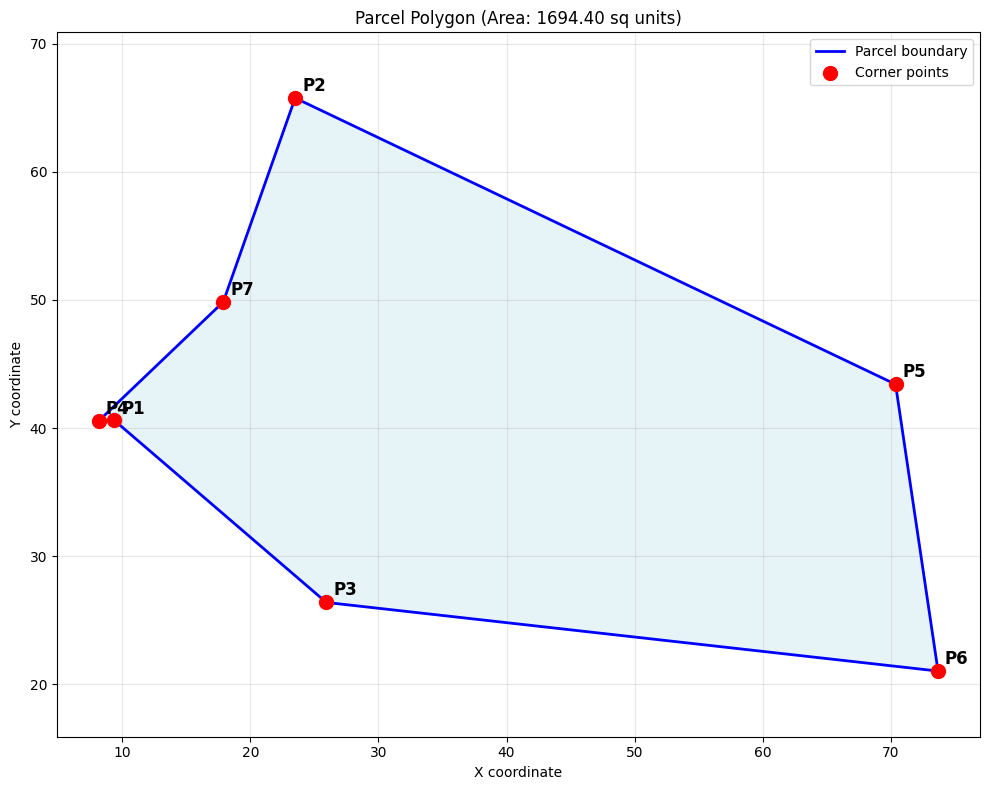

In [8]:
# np_sorted_2d_corners=sort__coordinates(o3d_parcel_corners)
# pgon=Polygon(np_sorted_2d_corners)
# Polygon(np_sorted_2d_corners)
# printf(f"This is the parcel area:{pgon.area}")
import numpy as np
from shapely.geometry import Polygon
import matplotlib.pyplot as plt

def sort_coordinates_clockwise(XY):
    """
    Sort 2D coordinates in clockwise order

    Parameters:
    XY: numpy array of shape (n, 2) with x,y coordinates

    Returns:
    Sorted coordinates in clockwise order
    """
    # Calculate center
    cx, cy = XY.mean(axis=0)

    # Calculate angles from center
    x, y = XY[:, 0], XY[:, 1]
    angles = np.arctan2(y - cy, x - cx)

    # Sort clockwise (descending angles)
    sorted_indices = np.argsort(-angles)

    return XY[sorted_indices]

# Extract 2D points from point cloud
print("Original corner points (3D):")
corner_points_3d = np.asarray(o3d_parcel_corners.points)
print(corner_points_3d)

# Take only X, Y coordinates
corners_2d = corner_points_3d[:, :2]
print("\n2D corner points (X, Y):")
print(corners_2d)

# Sort the coordinates
sorted_corners = sort_coordinates_clockwise(corners_2d)
print("\nSorted corner points (clockwise):")
print(sorted_corners)

# Create polygon
pgon = Polygon(sorted_corners)

# Print results
print(f"\n{'='*50}")
print(f"This is the parcel area: {pgon.area:.2f} square units")
print(f"Parcel perimeter: {pgon.length:.2f} units")
print(f"Is polygon valid: {pgon.is_valid}")
print(f"{'='*50}")

# Visualize
plt.figure(figsize=(10, 8))

# Plot polygon
x, y = pgon.exterior.xy
plt.plot(x, y, 'b-', linewidth=2, label='Parcel boundary')
plt.fill(x, y, alpha=0.3, fc='lightblue', ec='blue')

# Plot corner points
plt.scatter(corners_2d[:, 0], corners_2d[:, 1],
           c='red', s=100, zorder=5, label='Corner points')

# Add point labels
for i, (x, y) in enumerate(corners_2d):
    plt.annotate(f'P{i+1}', (x, y), xytext=(5, 5),
                textcoords='offset points', fontsize=12, fontweight='bold')

plt.xlabel('X coordinate')
plt.ylabel('Y coordinate')
plt.title(f'Parcel Polygon (Area: {pgon.area:.2f} sq units)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.axis('equal')
plt.tight_layout()
plt.show()

In [9]:
# Create 3D visualization with sorted points
sorted_corners_3d = corner_points_3d[np.argsort(-np.arctan2(
    corner_points_3d[:, 1] - corner_points_3d[:, 1].mean(),
    corner_points_3d[:, 0] - corner_points_3d[:, 0].mean()
))]

# Create line set for polygon
lines = []
for i in range(len(sorted_corners_3d) - 1):
    lines.append([i, i + 1])
lines.append([len(sorted_corners_3d) - 1, 0])  # Close polygon

line_set = o3d.geometry.LineSet()
line_set.points = o3d.utility.Vector3dVector(sorted_corners_3d)
line_set.lines = o3d.utility.Vector2iVector(lines)
line_set.colors = o3d.utility.Vector3dVector([[1, 1, 0] for _ in lines])

# Visualize
o3d.visualization.draw_geometries([pcd_selected, line_set, o3d_parcel_corners])

[Open3D WARNING] GLFW initialized for headless rendering.
[Open3D WARNING] GLFW Error: OSMesa: Library not found
[Open3D WARNING] Failed to create window
[Open3D WARNING] [DrawGeometries] Failed creating OpenGL window.


In [10]:
''''
Start reading from 207 pages
''''

SyntaxError: unterminated string literal (detected at line 3) (2593085974.py, line 3)